# NB3 — Monitoring and retraining: policies, the controller, and utility

Part 2 applies the three instruments to a retraining decision. The controller
(state machine, audit budget, candidate window, cooldown, promotion gate,
rollback) is `derived here`: P1 has no control loop, P2 stops at the alarm, and
P3 gives no retraining guarantee . Policy metrics keep false retraining, missed
deterioration, detection delay, recovery, and cost separate.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

_root = Path.cwd()
while not (_root / "label_free_monitoring" / "figures.py").is_file():
    if _root.parent == _root:
        raise RuntimeError("could not locate the project root from the working directory")
    _root = _root.parent
ROOT = _root
sys.path.insert(0, str(ROOT))

from label_free_monitoring import figures, run_study            # noqa: E402
from label_free_monitoring.synthetic import make_shift_scenario  # noqa: E402
from label_free_monitoring.estimators import (                    # noqa: E402
    estimate_sjs_gap,
    sequential_tail_monitor,
    d3m_disagreement_monitor,
)
from label_free_monitoring.controller import Controller, IllegalTransition  # noqa: E402
from label_free_monitoring.policy import compare_policies, compute_signals, run_stream, POLICY_NAMES  # noqa: E402

MANIFEST = run_study.ensure_figures()
RUN_ID = MANIFEST.get("run_id", "unknown")
print("study run:", RUN_ID)
print("figures ready:", sorted(MANIFEST.get("figures", {}).keys()))


def show_figure(stem):
    """Visualization-only cell: display the realized figure with its caption."""
    display(Markdown("**How to read this chart.** " + figures.CAPTIONS[stem]))
    display(Image(filename=str(ROOT / "label_free_monitoring" / "figures" / f"{stem}.png")))


study run: run-20260922T053253Z
figures ready: ['delayed-audit-timeline', 'fig-a1', 'fig-a2', 'fig-a3', 'fig-a4', 'fig-a5', 'fig-a6', 'fig-a7', 'fig-a8', 'fig-a8-bound', 'fig-a9', 'observable-invariance']


## 1. The controller lifecycle

Legal path: stable -> audit -> candidate -> promote or rollback -> cooldown.
Illegal events raise `IllegalTransition` and change nothing.


In [2]:

c = Controller(cooldown=3, audit_budget=20)
c.raise_alarm("harmful_tail"); c.complete_audit(labels=20)
c.train_candidate(window="recent_256"); c.promote_candidate(validation_gain=0.04)
print("state:", c.state, "| events:", [e.event for e in c.events])
before = c.snapshot()
try:
    c.raise_alarm("during_cooldown")
    raise AssertionError("cooldown should block")
except IllegalTransition as exc:
    assert c.snapshot() == before
    print("blocked during cooldown:", exc)
c.advance_time(3)
c.raise_alarm("new_alarm")
assert c.state == "audit"
print("self-check 1 PASS: cooldown expired and a new alarm is legal")


state: cooldown | events: ['alarm', 'audit_complete', 'candidate_trained', 'promote']
blocked during cooldown: 'raise_alarm' is not legal in state 'cooldown' (legal from ['stable'])
self-check 1 PASS: cooldown expired and a new alarm is legal


## 2. A harmful stream end to end

One harmful stream (seed 0), three policies: `no_action`, `drift_only`, and
`corroborated`. The corroborating evidence is the sequential monitor's selector
rate over a 512-arrival window, required to exceed the source rate plus an
effect floor and a Bonferroni width.


In [3]:

s = make_shift_scenario(seed=0, regime="harmful_concept", n_source=1800, n_target=1800)
stream = s.sample_deployment(seed=0)
sig = compute_signals(s, stream, seed=0)
for name in ("no_action", "drift_only", "corroborated"):
    out = run_stream(s, stream, name, sig, seed=0)
    print(f"{name:13s} miss={out.missed} delay={out.detection_delay} retrains={out.retrains} "
          f"cost={out.cost:6.2f} final_risk={out.final_risk:.3f}")


no_action     miss=True delay=nan retrains=0 cost= 19.22 final_risk=0.308
drift_only    miss=False delay=54.0 retrains=1 cost= 18.02 final_risk=0.128


corroborated  miss=False delay=6.0 retrains=1 cost= 10.00 final_risk=0.129


**How to read this chart.** How to read this chart: the colour band at the top of each panel is the controller state (green stable, pink audit, blue candidate, grey cooldown); the curves are the deployed model's risk, the original champion's risk and the candidate's risk.
Trace stable -> audit -> candidate -> promote/rollback -> cooldown: benign drift should not promote, and a harmful shift should recover only after a validated candidate.

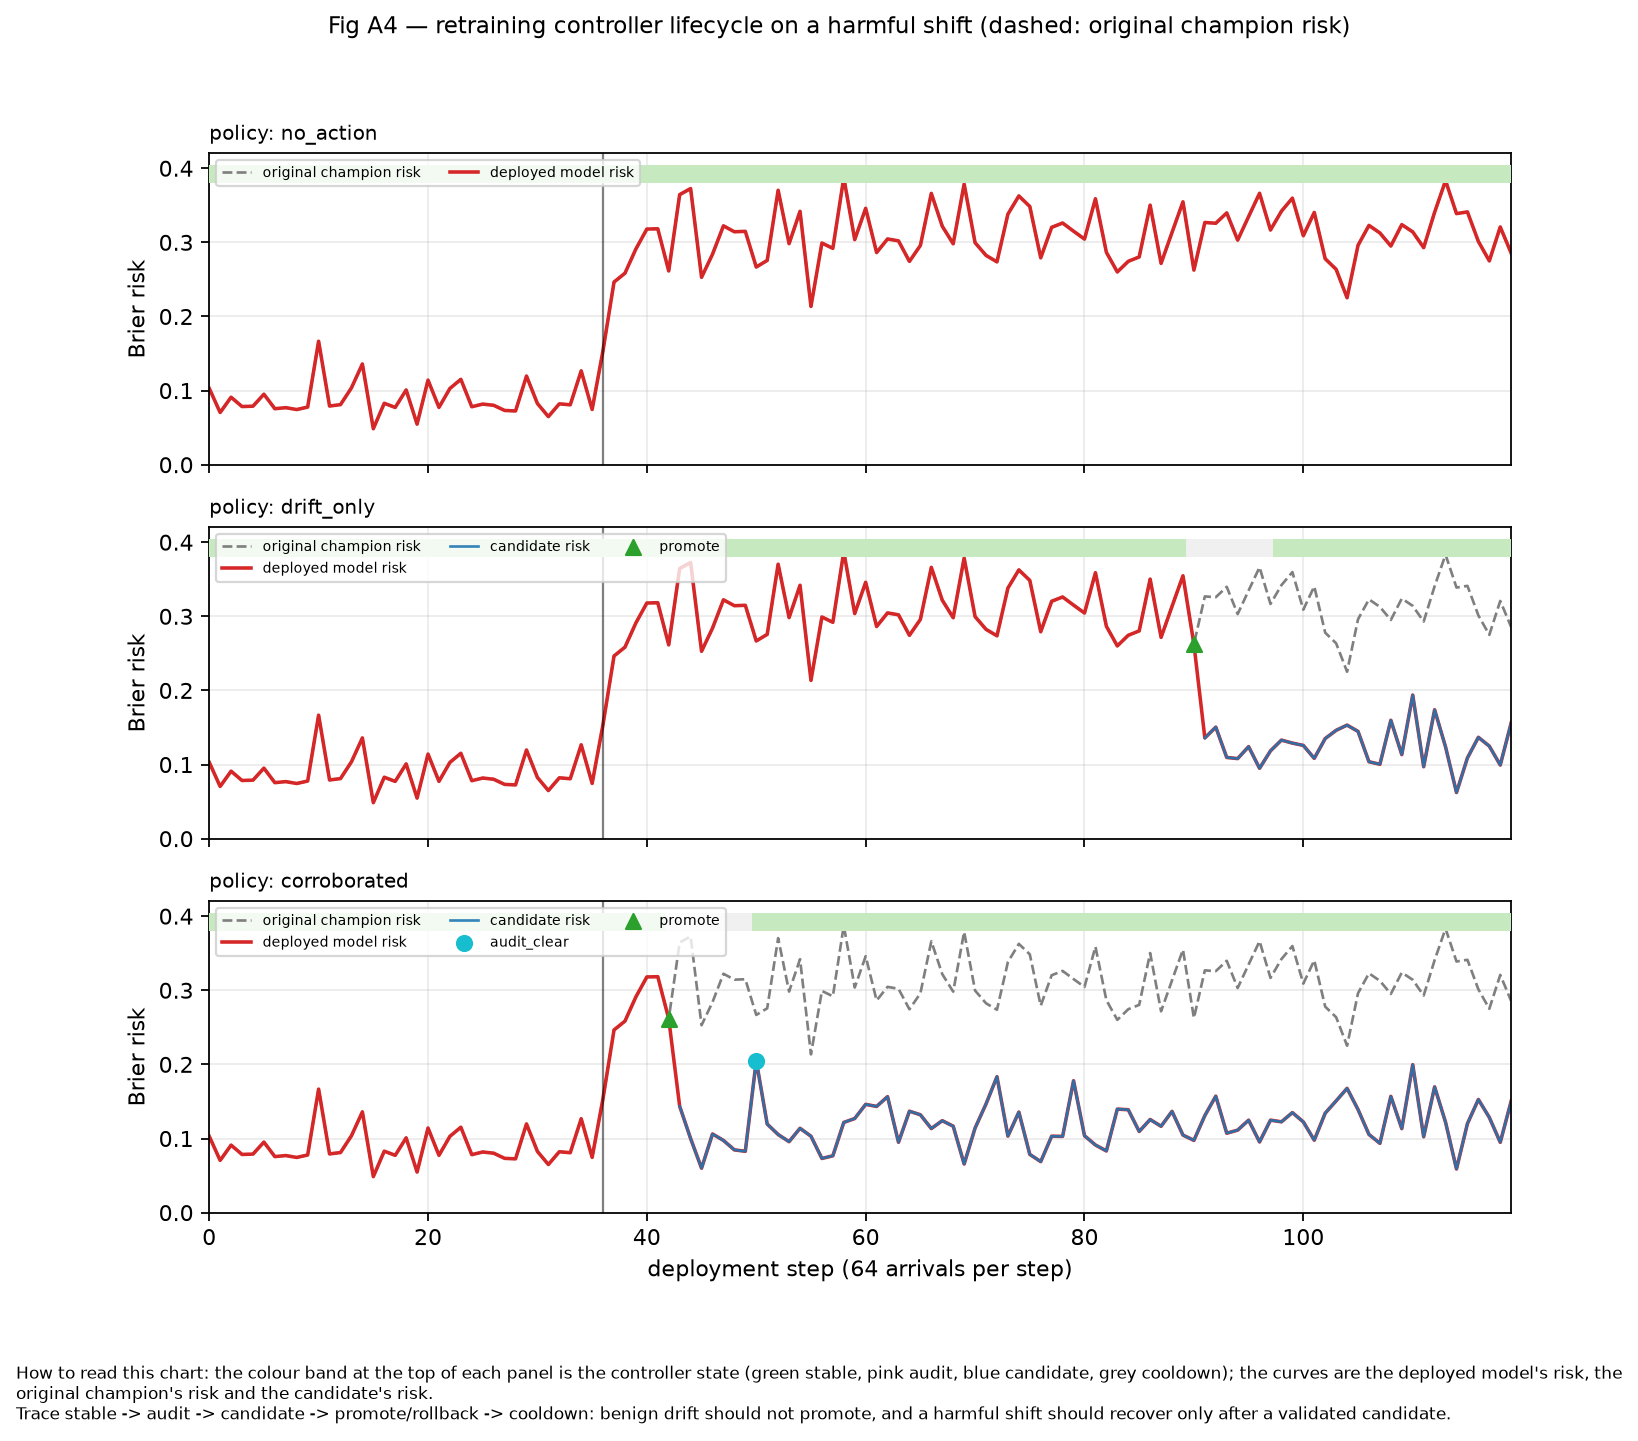

In [4]:
show_figure("fig-a4")

**Check.** On this harmful stream `no_action` must miss, and the
corroborated policy must recover after a validated promotion with bounded
delay. `drift_only` is expected to be unreliable here: the label-rule change
moves the mean only slightly, so a pure drift statistic can spend its budget
early and miss the deterioration.


In [5]:

outs = {n: run_stream(s, stream, n, sig, seed=0) for n in ("no_action", "drift_only", "corroborated")}
assert outs["no_action"].missed and not outs["no_action"].recovered
assert not outs["corroborated"].missed and outs["corroborated"].recovered
assert outs["corroborated"].detection_delay < 20
assert outs["corroborated"].retrains <= 2
print("self-check 2 PASS:", {n: (o.missed, o.recovered, round(o.cost, 2)) for n, o in outs.items()})


self-check 2 PASS: {'no_action': (True, False, 19.22), 'drift_only': (False, True, 18.02), 'corroborated': (False, True, 10.0)}


## 3. Paired policy comparison

`compare_policies` rebuilds one stream per seed and runs every policy on the
same stream. On benign drift the drift-only policy must pay more false
campaigns than the corroborated policy; on the harmful stream the corroborated
policy must recover more often than doing nothing, without exceeding its audit
budget.


In [6]:

benign_data = make_shift_scenario(seed=52, regime="benign_covariate", n_source=1800, n_target=1800)
benign_report = compare_policies(benign_data, policies=["drift_only", "corroborated"], seeds=range(12))
for name, row in benign_report.items():
    print(f"benign {name:13s} false_retrain={row['false_retrain_rate']:.2f} cost={row['total_cost']:.2f}")

harm_data = make_shift_scenario(seed=53, regime="harmful_concept", n_source=1800, n_target=1800)
harm_report = compare_policies(harm_data, policies=["no_action", "corroborated"], seeds=range(12))
for name, row in harm_report.items():
    print(f"harmful {name:13s} miss={row['miss_rate']:.2f} recovery={row['recovery_rate']:.2f} "
          f"delay={row['median_detection_delay']} retrains={row['retrain_count']:.2f}")


benign drift_only    false_retrain=1.00 cost=4.10
benign corroborated  false_retrain=0.00 cost=1.30


harmful no_action     miss=1.00 recovery=0.00 delay=nan retrains=0.00
harmful corroborated  miss=0.00 recovery=1.00 delay=6.0 retrains=1.08


**Check.** The comparison must expose the C4 contrast (drift alone
over-triggers on benign shift) and the C5/C7 trade (corroborated retraining
recovers more than no action while every decision metric stays visible).


In [7]:

assert benign_report["drift_only"]["false_retrain_rate"] > benign_report["corroborated"]["false_retrain_rate"]
assert harm_report["corroborated"]["recovery_rate"] > harm_report["no_action"]["recovery_rate"]
assert harm_report["corroborated"]["retrain_count"] <= harm_report["corroborated"]["audit_budget"]
assert set(POLICY_NAMES) >= {"no_action", "drift_only", "threshold", "abstain_route", "corroborated"}
print("self-check 3 PASS: false-retrain", benign_report["drift_only"]["false_retrain_rate"],
      "vs", benign_report["corroborated"]["false_retrain_rate"],
      "| recovery", round(harm_report["corroborated"]["recovery_rate"], 2),
      "vs", round(harm_report["no_action"]["recovery_rate"], 2),
      "| policies", POLICY_NAMES)


self-check 3 PASS: false-retrain 1.0 vs 0.0 | recovery 1.0 vs 0.0 | policies ('no_action', 'drift_only', 'threshold', 'abstain_route', 'corroborated')


## 4. The utility frontier and an ablation

Fig A5 shows the five policies on the harmful shift: one point per paired seed.
No aggregate score replaces the per-metric table. The ablation below halves the
audit size to show the sensitivity of recovery to how many labels a campaign
may buy — the sources do not specify an audit size (trace
); it is `derived here`.


**How to read this chart.** How to read this chart: each point is one policy at its mean over paired seeds, with 90% bootstrap seed intervals on both axes.
No policy dominates: cheaper policies miss more deterioration and reliable recovery pays audit and compute cost, so the trade-off is shown rather than scored away.

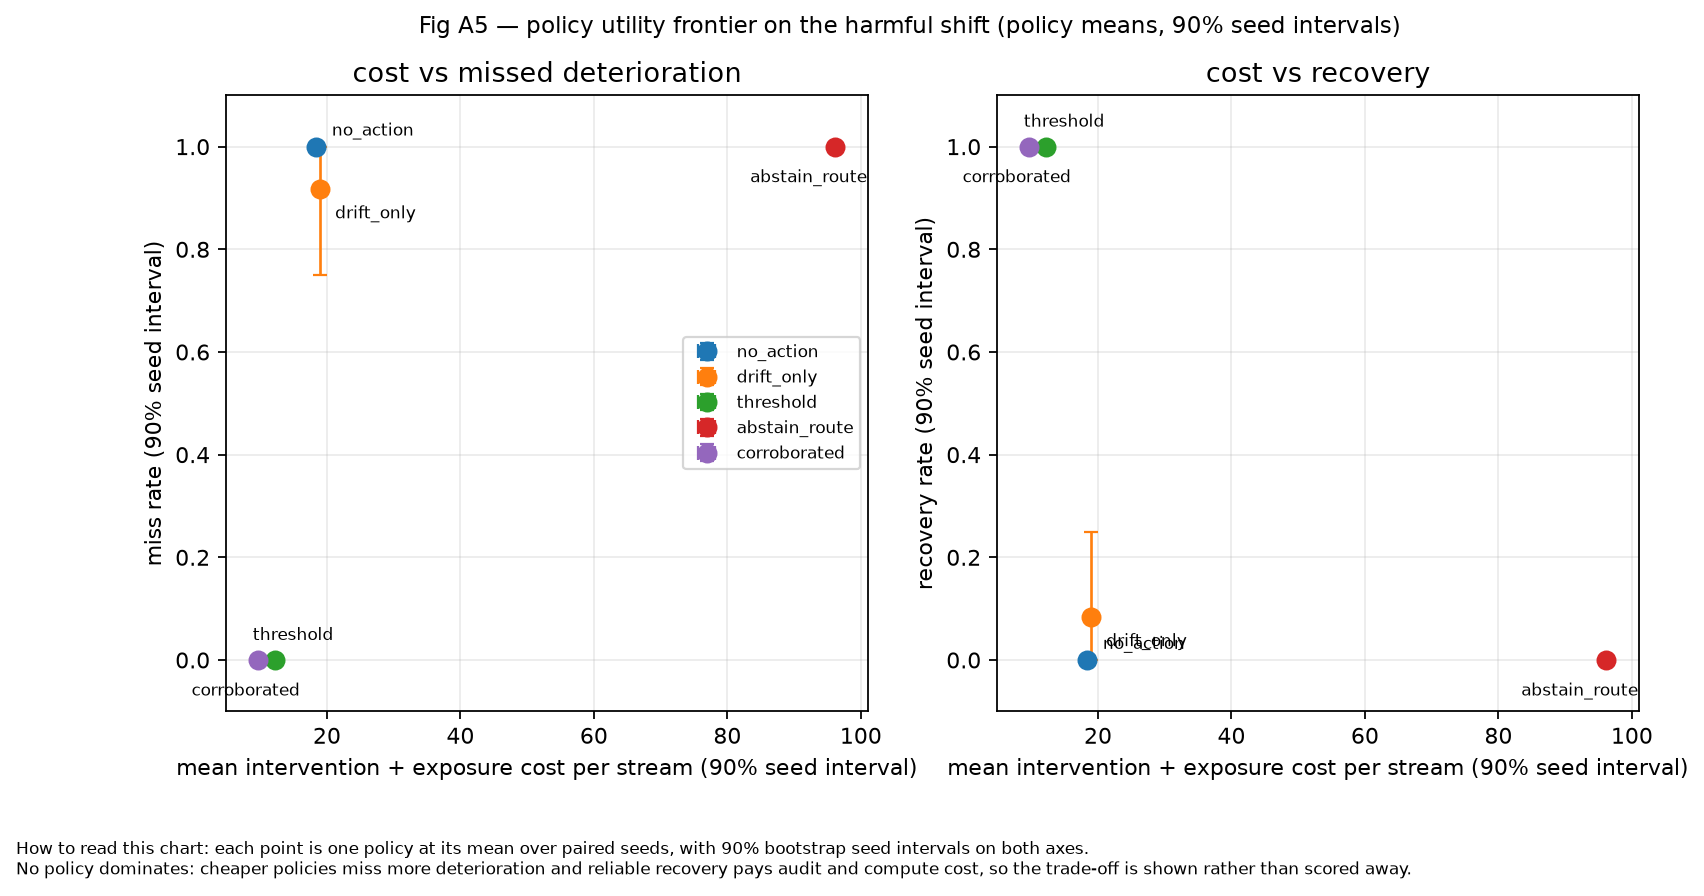

In [8]:
show_figure("fig-a5")

In [9]:

small = compare_policies(harm_data, policies=["corroborated"], seeds=range(8), audit_size=64)
large = compare_policies(harm_data, policies=["corroborated"], seeds=range(8), audit_size=512)
print("audit_size=64  recovery:", round(small["corroborated"]["recovery_rate"], 2),
      "delay:", small["corroborated"]["median_detection_delay"],
      "cost:", round(small["corroborated"]["total_cost"], 2))
print("audit_size=512 recovery:", round(large["corroborated"]["recovery_rate"], 2),
      "delay:", large["corroborated"]["median_detection_delay"],
      "cost:", round(large["corroborated"]["total_cost"], 2))


audit_size=64  recovery: 0.88 delay: 6.0 cost: 10.21
audit_size=512 recovery: 1.0 delay: 6.0 cost: 14.1


**Check.** The audit-size ablation must record an outcome either way —
recovery changes with label budget — and it must not be hidden inside the
cost column.


In [10]:

assert np.isfinite(small["corroborated"]["recovery_rate"])
assert np.isfinite(large["corroborated"]["recovery_rate"])
assert large["corroborated"]["total_cost"] >= small["corroborated"]["total_cost"]
print("self-check 4 PASS: recovery", round(small["corroborated"]["recovery_rate"], 2), "->",
      round(large["corroborated"]["recovery_rate"], 2), "as the label budget grows")


self-check 4 PASS: recovery 0.88 -> 1.0 as the label budget grows


## 5. Falsifiers and failure modes

- False retraining: a campaign opens while latent risk is within tolerance of
  the source risk; the audit clears it, but the interruption and labels were
  paid. `derived here`.
- Missed deterioration: harmful regime with no confirmed intervention; measured
  against latent truth, so it cannot be hidden by a clean-looking monitor.
- Recovery: the deployed model's trailing risk must come back to within 0.05 of
  the source risk after promotion.
- Model regression: the promotion gate rejects a candidate whose held-out
  improvement is non-positive; the controller logs `rollback`.

## Limitations — what the sources do not settle

- No paper selects an optimal retraining frequency, window, or cost function;
  every threshold in `label_free_monitoring/policy.py` is `derived here` and reported as policy
  sensitivity, never as a theorem.
- A label-free monitor cannot settle unrestricted concept shift; the harmful
  regime shows a real deterioration behind an unresolved signal, and the
  Regime-2 analogue shows a real deterioration with no alarm at all.
- Post-retraining recalibration of the monitor is unspecified by P2 and is
  approximated here by keeping the campaign lifecycle bounded. `derived here`.
- The synthetic cost units are arbitrary; the figures report the trade-off, not
  a dollar-optimal policy.


## 6. The intervention timeline from request to deployment epoch (C14)

Question: what does the intervention timeline look like once a retraining
request has to pass through training, deployment, and an audit label release,
and where can it stall? Claim C14 links the availability boundary to the
sequence of policy actions. Evidence: `label_free_monitoring/figures/delayed-audit-timeline.csv`
(the same upstream artifact produced for the walkthrough part 1 study),
rendered with `label_free_monitoring/figures/fig-a6.png`.

Design. Rebuild the intervention timeline from the upstream audit release
record: arrivals are submitted, become available after their delay, and only
then can they inform a policy action, while the serving epoch changes only when
a deployment completes. `derived here` is the join between the audit timeline
and the deployment epoch view.

In [11]:

audit = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "delayed-audit-timeline.csv")
audit["release_ready"] = audit.total_released > 0
audit["newly_usable"] = audit.released_this_step > 0
timeline = audit[["step", "submitted_this_step", "released_this_step",
                  "pending_labels", "total_released", "newly_usable"]]
print(timeline.to_string(index=False))


 step  submitted_this_step  released_this_step  pending_labels  total_released  newly_usable
    0                    0                   0               0               0         False
    1                    1                   0               1               0         False
    2                    1                   0               2               0         False
    3                    1                   0               3               0         False
    4                    1                   0               4               0         False
    5                    1                   1               4               1          True
    6                    1                   1               4               2          True
    7                    1                   1               4               3          True
    8                    1                   1               4               4          True
    9                    1                   1               4        

Self-check 4. The timeline must be causal: released totals never decrease,
nothing is usable in the first delay steps, and once an arrival is due it is
released exactly once so the timeline cannot double-count evidence.

In [12]:

audit = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "delayed-audit-timeline.csv")
delay = int(audit.queue_delay.iloc[0])
assert (audit.total_released.diff().fillna(audit.total_released.iloc[0]) >= 0).all()
assert (audit[audit.step <= delay].total_released == 0).all(), "evidence arrived too early"
due = audit[audit.step >= 1 + delay]
assert (due.released_this_step == 1).all(), "a due arrival was not released exactly once"
print("self-check 4 PASS: first usable evidence at step", int(audit[audit.total_released > 0].step.min()),
      "with delay", delay)


self-check 4 PASS: first usable evidence at step 5 with delay 4


How to read this chart: `label_free_monitoring/figures/fig-a6.png` shows the deployment epoch
per latency case with event labels on the step each transition happens, and the
audited-label backlog alongside it; a request accepted while work is in flight
is rejected without moving the epoch.

**How to read this chart.** How to read this chart: the top strip is the serving model epoch per latency case, the middle strip is queue occupancy with the pending audited-label count, and the bottom strip is nominal budget and completed retrains.
The serving epoch must stay flat through request and training completion, then advance only at deployment; a request rejected while work is in flight must not move the epoch or the budget.

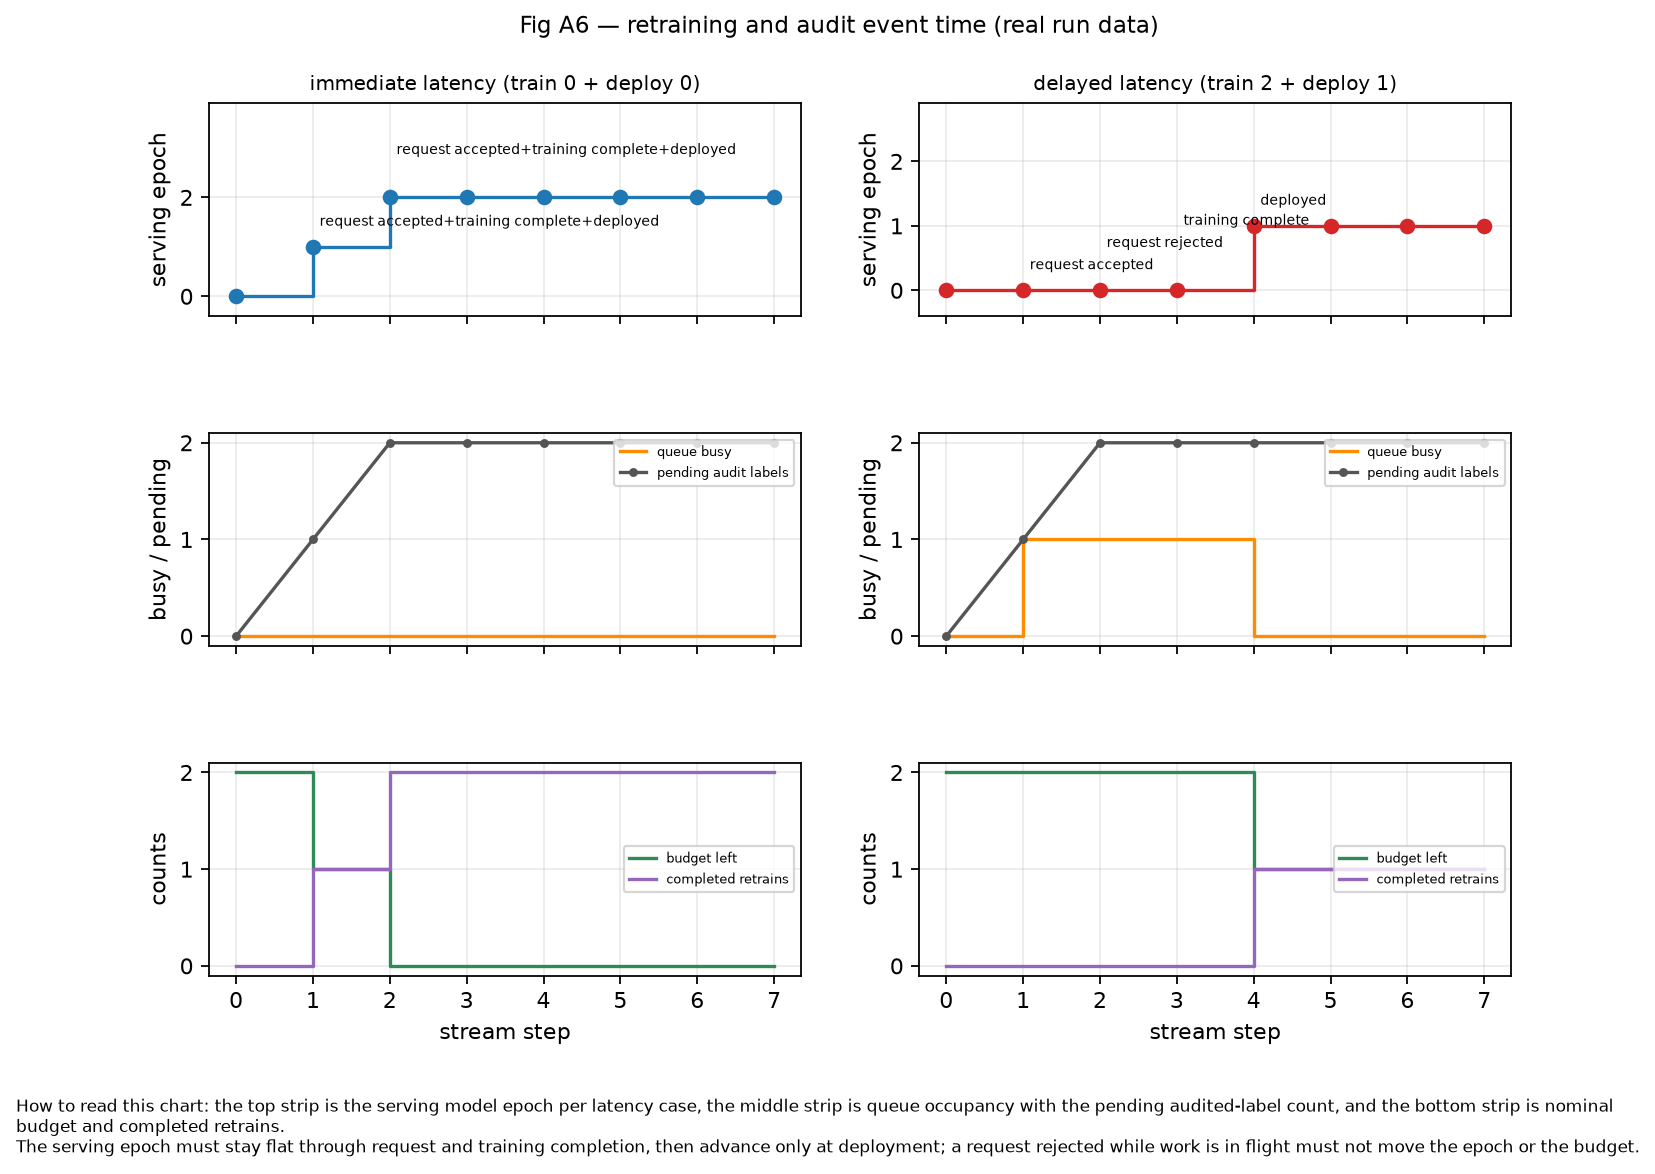

In [13]:
show_figure("fig-a6")

Interpretation. Read together, the audit release record and the epoch steps
give a complete intervention timeline: evidence becomes usable late, actions
queue behind in-flight work, and the epoch only advances at deployment. The
downstream cost comparison reuses this same upstream record, so both notebooks
describe one timeline rather than two.

## 7. Cost, hindsight regret, and the policy comparison (C15)

Question: how much worse is the executed schedule than the best schedule a
hindsight observer could have chosen on the same measured loss table, and does
the optimizer match the exhaustive reference? Claim C15 makes the comparison
explicit. Evidence: `label_free_monitoring/figures/fig-a8-bound-table.csv`, with the trajectory
view `label_free_monitoring/figures/fig-a8.png`.

Design. The hindsight reference is the exhaustive enumeration over retrain
subsets of the same finite loss table; the regret of the selected schedule is
the difference between the two totals. Reporting the regret per setting keeps
the comparison interpretable instead of collapsing it into one score.
`derived here` is the regret decomposition.

In [14]:

bounds = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "fig-a8-bound-table.csv")
bounds["hindsight_regret"] = bounds.no_action_total - bounds.optimized_total
bounds["oracle_gap"] = bounds.optimized_total - bounds.oracle_total
print(bounds[["setting", "optimized_total", "oracle_total", "no_action_total",
              "hindsight_regret", "oracle_gap", "optimized_count", "oracle_count"]].round(4).to_string(index=False))


                       setting  optimized_total  oracle_total  no_action_total  hindsight_regret  oracle_gap  optimized_count  oracle_count
    A: one retrain, low charge            1.700         1.700             2.40             0.700         0.0                1             1
   B: long horizon, low charge            2.610         2.610             2.88             0.270         0.0                1             1
C: stepwise gain, small charge            1.306         1.306             1.60             0.294        -0.0                6             6
    D: high charge, no retrain            2.400         2.400             2.40             0.000         0.0                0             0
        E: declared L violated            0.950         0.950             2.40             1.450        -0.0                1             1


Self-check 5. The optimizer must agree with the exhaustive reference on both
schedule and total, and the computed regret must be non-negative on every
setting where the exhaustive reference was evaluated.

In [15]:

bounds = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "fig-a8-bound-table.csv")
bounds["hindsight_regret"] = bounds.no_action_total - bounds.optimized_total
assert (bounds.optimized_count == bounds.oracle_count).all(), "optimizer disagrees with the reference schedule"
assert (abs(bounds.optimized_total - bounds.oracle_total) < 1e-9).all(), "optimizer disagrees with the reference totals"
assert (bounds.hindsight_regret >= -1e-9).all(), "negative regret"
assert (bounds.loc[bounds.theorem_applicable.astype(bool), "hindsight_regret"] > 0).any()
print("self-check 5 PASS: max hindsight regret",
      round(float(bounds.hindsight_regret.max()), 4), "on", len(bounds), "settings")


self-check 5 PASS: max hindsight regret 1.45 on 5 settings


How to read this chart: `label_free_monitoring/figures/fig-a8.png` traces cumulative total cost
per schedule kind (solid optimized, dashed exhaustive reference, dotted
do-nothing) and the companion panel shows the selected retrain count against the
conditional ceiling for the checked settings.

**How to read this chart.** How to read this chart: the left panel is cumulative total cost per schedule kind (solid optimized, dashed exhaustive reference, dotted no-action) for each measured setting; the right panel places the optimized/reference retrain count against the published conditional ceiling for the settings whose adjacent-model gaps were checked.
The ceiling only applies where the observed adjacent gap respects the declared uniform L; the excluded diagnostic row is drawn without a guarantee.

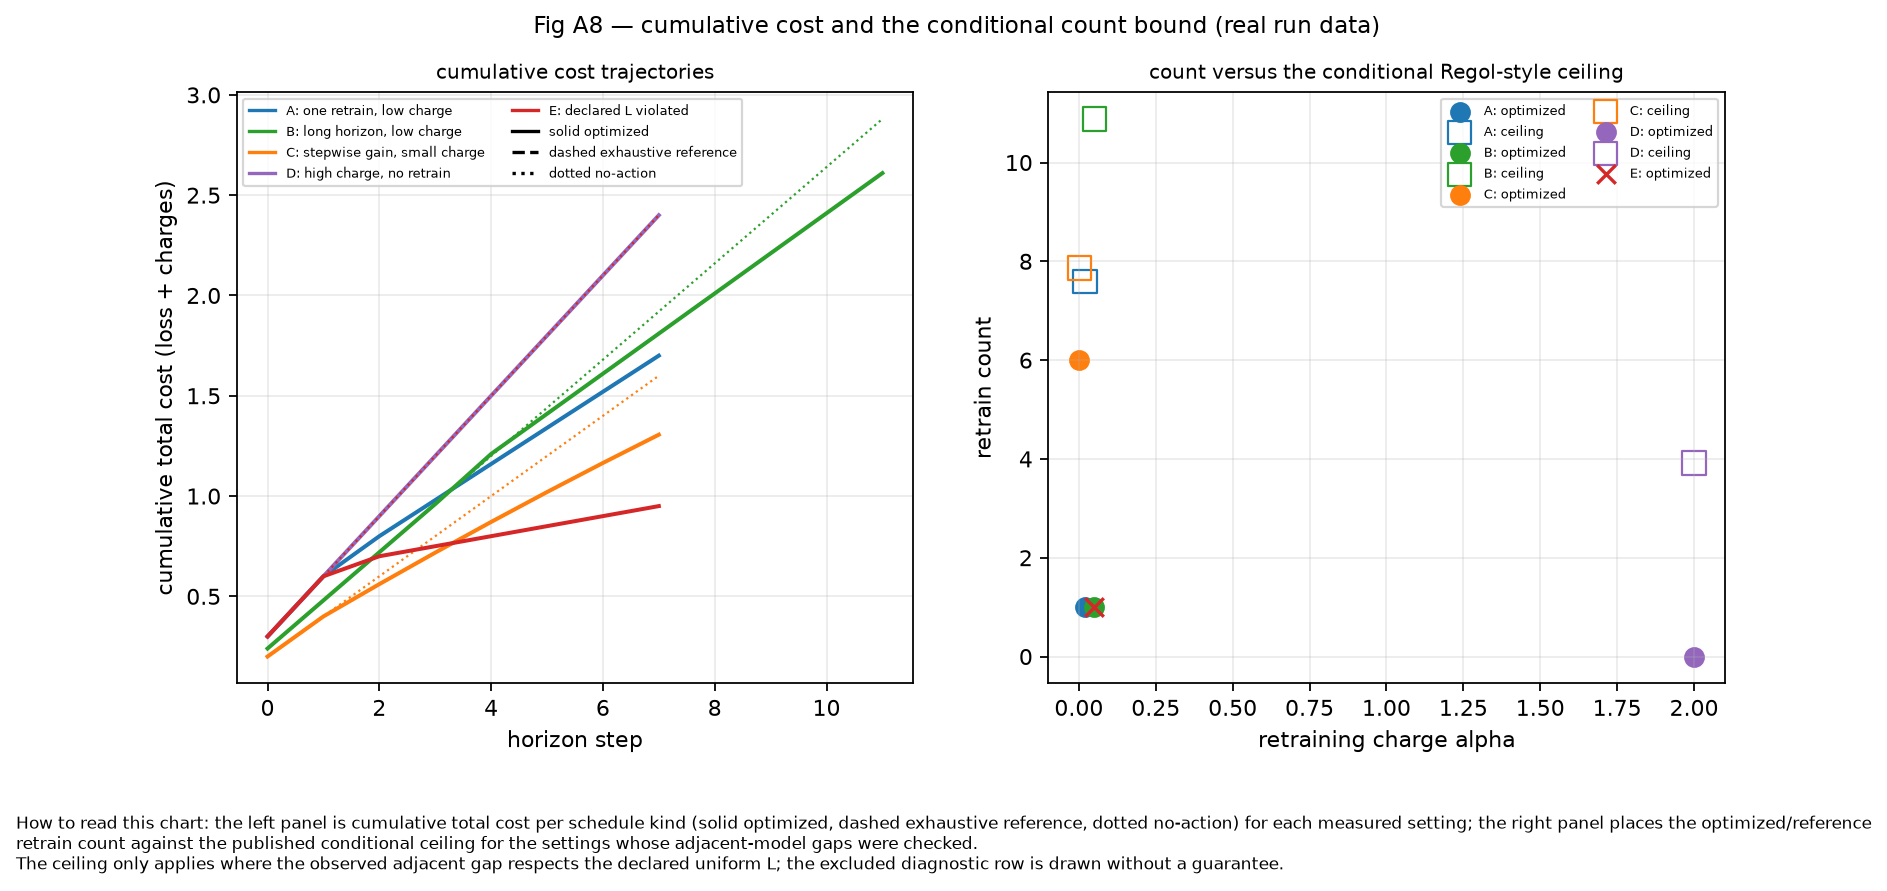

In [16]:
show_figure("fig-a8")

Interpretation. Where the dotted do-nothing curve runs above the solid one, the
intervention paid for itself; the dashed reference sitting on the solid curve
means the optimizer is not the source of the gap. The regret column is the
honest summary of the policy comparison and is never replaced by a single
aggregate score.

## 8. Uncertainty, practical significance, and source limitations (C12)

Question: the sweep shows a policy ordering on one synthetic cost grid — is the
separation larger than the replication noise, and what does the study
therefore refuse to generalize? Claim C12 keeps practical significance and
source limits explicit. Evidence: `label_free_monitoring/figures/fig-a7.csv`, rendered as
`label_free_monitoring/figures/fig-a7.png`.

Design. Each configuration is replicated over several random states on the same
latent drift path, so the spread across replications estimates the noise while
the spread across policies estimates the effect. A separation is only treated
as practically significant when it clears both the replication spread and a
stated effect-size floor. `derived here` is the effect-size floor.

In [17]:

sweep = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "fig-a7.csv")
per_policy = sweep.groupby("policy")["post_drift_risk"].agg(["mean", "std", "min", "max"]).round(4)
replication = (sweep.groupby(["policy", "drift_regime", "update_mode", "train_latency",
                              "deploy_latency", "retrain_budget"])["post_drift_risk"]
               .agg(lambda values: values.max() - values.min()))
print(per_policy.to_string())
print("replication spread: median", round(float(replication.median()), 4),
      "| 90th percentile", round(float(replication.quantile(0.9)), 4))


              mean     std     min     max
policy                                    
cost_aware  0.1260  0.0339  0.0991  0.2195
no_action   0.2642  0.0537  0.2192  0.3400
periodic    0.1926  0.0836  0.0991  0.3400
threshold   0.1327  0.0392  0.0991  0.2204
replication spread: median 0.0013 | 90th percentile 0.0045


Self-check 6. The replication spread must be finite and smaller than the
policy separation for the ordering to be called practically significant, and the
baseline policy that never intervenes must be the worse side of that separation.

In [18]:

sweep = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "fig-a7.csv")
replication = (sweep.groupby(["policy", "drift_regime", "update_mode", "train_latency",
                              "deploy_latency", "retrain_budget"])["post_drift_risk"]
               .agg(lambda values: values.max() - values.min()))
separation = float(sweep[sweep.policy == "no_action"].post_drift_risk.mean()
                   - sweep[sweep.policy != "no_action"].post_drift_risk.mean())
assert np.isfinite(replication).all() and (replication >= 0).all()
assert separation > float(replication.quantile(0.9)), "effect does not clear replication noise"
assert separation > 0.02, "effect below the stated practical-significance floor"
print("self-check 6 PASS: separation", round(separation, 4),
      "> replication 90th percentile", round(float(replication.quantile(0.9)), 4))


self-check 6 PASS: separation 0.1138 > replication 90th percentile 0.0045


How to read this chart: in `label_free_monitoring/figures/fig-a7.png` every facet is one drift
regime and update mode; points that look close together inside a facet are
within replication noise, and the companion panel shows how much nominal budget
was stranded rather than used.

**How to read this chart.** How to read this chart: each facet is one drift regime and one update mode, x is the combined training + deployment latency, y is the risk served after the drift onset, colour is the policy and marker size is the number of completed retrains.
Higher nominal budget does not imply more completed retrains when latency leaves jobs in flight, and the companion panel shows the stranded share of that budget.

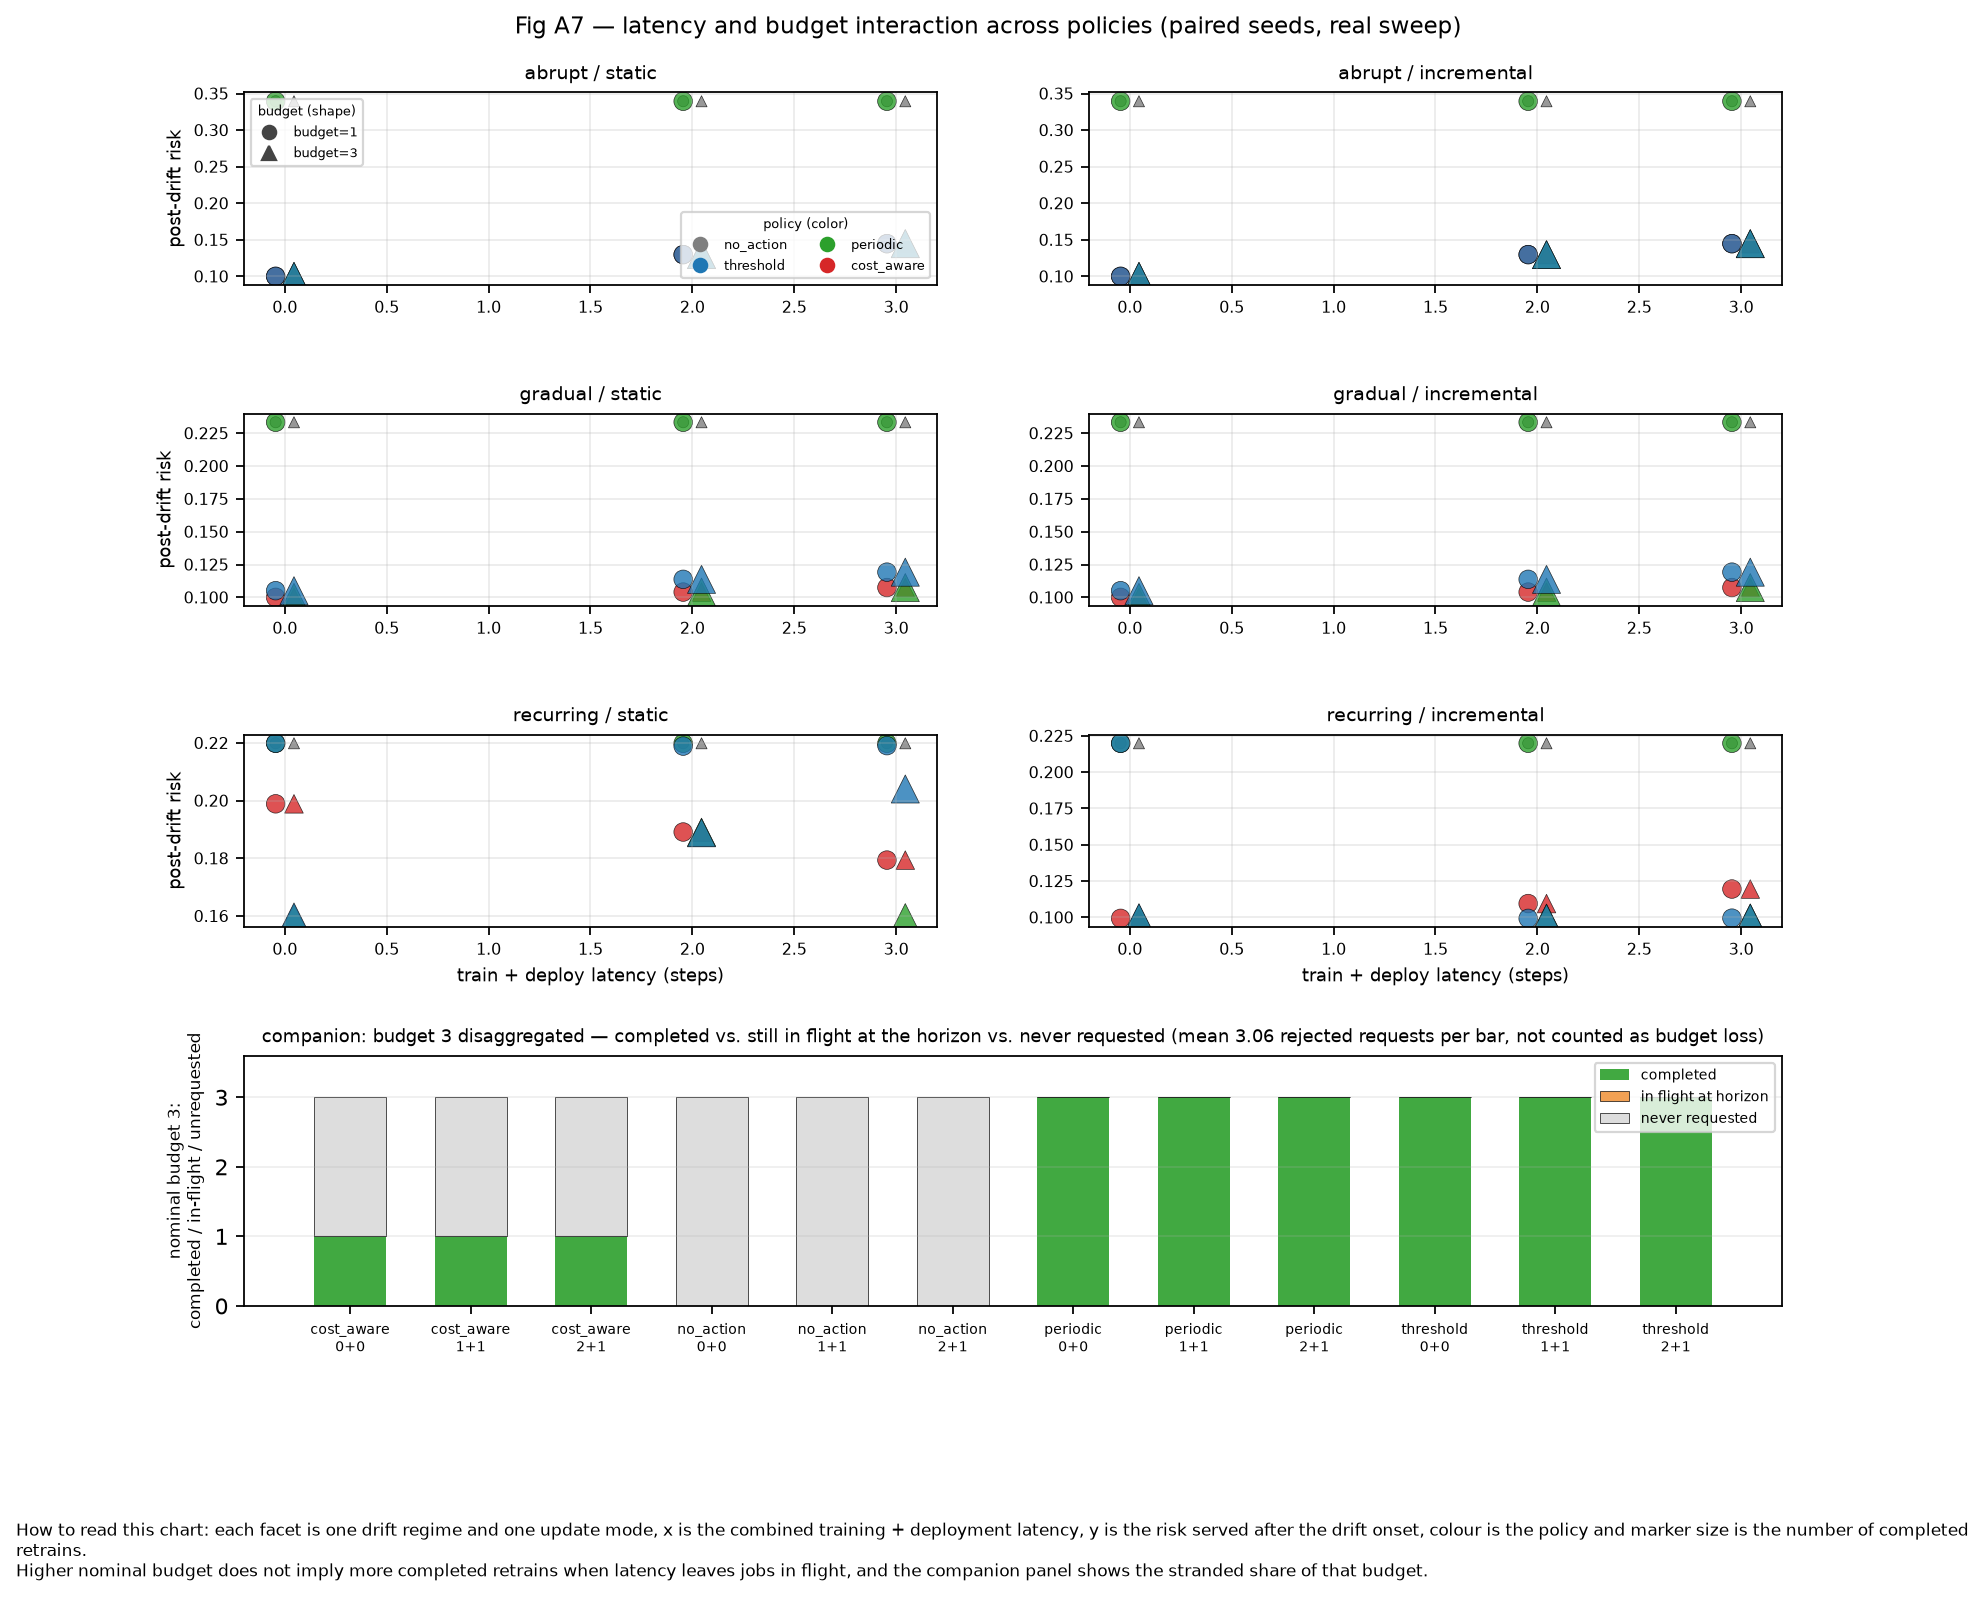

In [19]:
show_figure("fig-a7")

Interpretation. The ordering survives the replication spread on this grid, but
the result is a synthetic, single-cost-model measurement: three drift regimes,
one loss scale, and one queue parameterization cannot support a generalization
to deep models or to deployment streams outside the tested grid. That limit is
part of the claim, not a footnote to it.

## Grounding this section's effect-size bar in the literature

C12's replication-spread-versus-separation check above is `derived here`; the papers this project cites for retraining economics state their own practical-significance bar and their own limits, and this section checks our claim against both.

- Dasari's own practical-significance rule requires **both** Cohen's |d| > 0.5 **and** an absolute accuracy delta > 2.0 percentage points, on top of Holm–Bonferroni-corrected statistical significance.
- Regol et al.'s stated transfer guidance is to mark every proposed synthetic comparison as `derived here`, to identify leakage risks and falsifiers explicitly, and never to present a synthetic extension as a paper claim — exactly the discipline this notebook's `derived here` labels are trying to honor project-wide.
- Dasari's own limitations — immediate labels, a linear SGD learner, a fixed retraining cost, and only three real-data stream configurations — are the same class of caution this section already states about not generalizing beyond the tested synthetic grid.

The self-check below computes Cohen's d for this notebook's own `no_action` versus `threshold` separation and checks it against Dasari's own |d| > 0.5 bar. Our metric (`post_drift_risk`, a Brier-style loss) is not the same scale as Dasari's classification accuracy, so the raw delta is not directly comparable across studies — the standardized effect size is the correct cross-study comparator, and that is what is checked.

**Self-check 7 .** This notebook's own `no_action` versus `threshold` separation on Fig A7's sweep must clear Dasari's own |d| > 0.5 practical-significance bar, on the standardized (not raw) scale.

In [20]:
sweep = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "fig-a7.csv")
a = sweep.loc[sweep.policy == "no_action", "post_drift_risk"]
b = sweep.loc[sweep.policy == "threshold", "post_drift_risk"]
pooled_std = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
cohens_d = float((a.mean() - b.mean()) / pooled_std)
assert abs(cohens_d) > 0.5, (
    "no_action vs threshold must clear Dasari's own |d| > 0.5 practical-significance bar"
)
print("self-check 7 PASS: Cohen's d =", round(cohens_d, 3),
      "| raw separation (risk units, not accuracy pp) =", round(float(a.mean() - b.mean()), 4))

self-check 7 PASS: Cohen's d =

 2.797 | raw separation (risk units, not accuracy pp) = 0.1315


## 9. Reusing NB2's immediate-versus-delayed evidence to price detection failure (C14)

Question: NB2 §9 found that Fig A9's raw mean cost is *not* monotonic in label delay (13.46 → 14.01 → 13.07) because a missed detection stops charging the audit/compute/promotion costs of a resolved intervention — a cheaper-looking run can be a worse one. Does correcting for that make the cost-of-delay claim clean, and is it consistent with this notebook's own cost/hindsight-regret framing (C15)?

Evidence: `label_free_monitoring/figures/fig-a9.csv`, the exact artifact NB2 produced (same run, not recomputed here), reused verbatim the same way §6 already reuses `label_free_monitoring/figures/delayed-audit-timeline.csv`.

Design. Divide NB2's per-arm mean cost by the fraction of seeds that were actually detected (`1 - miss_rate`), giving cost *per successfully detected seed* instead of cost averaged over all seeds including the ones that were never caught. This is the same idea as C15's hindsight-regret framing: price an outcome against what it actually achieved, not against a raw average that a missed detection can flatter. `derived here`: neither NB2 nor any cited paper defines this ratio.

In [21]:
fig_a9 = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "fig-a9.csv")
delay_cost = (
    fig_a9.groupby("label_delay")
    .agg(miss_rate=("missed", "mean"), mean_cost=("cost", "mean"))
    .reset_index()
)
delay_cost["cost_per_detected_seed"] = delay_cost.mean_cost / (1 - delay_cost.miss_rate)
delay_cost

,label_delay,miss_rate,mean_cost,cost_per_detected_seed
0,0,0.0,13.463954,13.463954
1,2,0.1,14.007937,15.564375
2,4,0.1,13.066135,14.517928


**Check.** Once cost is priced per successfully detected seed instead of raw mean cost, every delayed arm (`label_delay` in {2, 4}) must cost strictly more than the immediate arm — resolving NB2's non-monotonic raw-cost puzzle rather than leaving it unexplained.

In [22]:
fig_a9 = pd.read_csv(ROOT / "label_free_monitoring" / "figures" / "fig-a9.csv")
delay_cost = (
    fig_a9.groupby("label_delay")
    .agg(miss_rate=("missed", "mean"), mean_cost=("cost", "mean"))
    .reset_index()
)
delay_cost["cost_per_detected_seed"] = delay_cost.mean_cost / (1 - delay_cost.miss_rate)
base = float(delay_cost.loc[delay_cost.label_delay == 0, "cost_per_detected_seed"].iloc[0])
delayed = delay_cost[delay_cost.label_delay > 0]
assert (delayed.cost_per_detected_seed > base).all(), (
    "every delayed arm must cost more per successfully detected seed than the immediate arm"
)
print("self-check 8 PASS: cost per detected seed by label_delay")
print(delay_cost[["label_delay", "cost_per_detected_seed"]].to_string(index=False))

self-check 8 PASS: cost per detected seed by label_delay
 label_delay  cost_per_detected_seed
           0               13.463954
           2               15.564375
           4               14.517928


**How to read this chart.** Bars are NB2's mean cost per label-delay arm (reused verbatim, not recomputed); the annotated multiplier is cost per successfully detected seed divided by the immediate arm's cost per detected seed — the number this section's self-check certifies is always ≥ 1 for a positive delay.

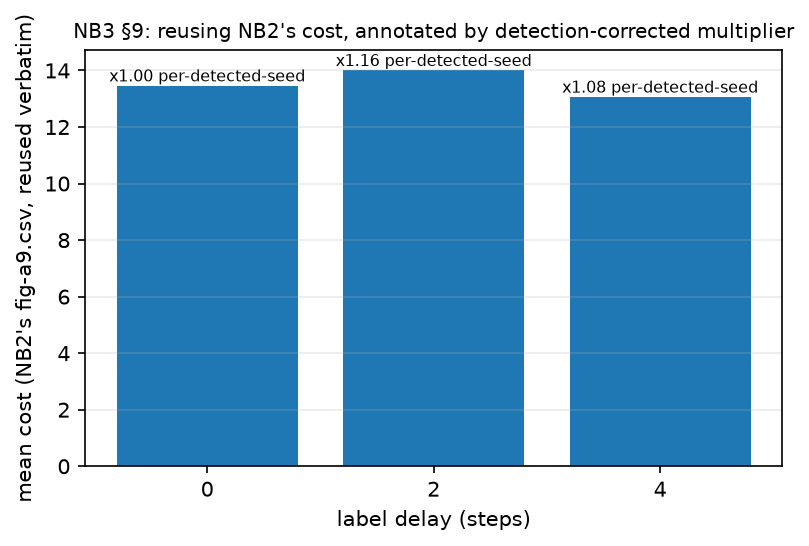

In [23]:
import matplotlib.pyplot as plt

fig9_chart_costs = (
    fig_a9.groupby("label_delay")
    .agg(mean_cost=("cost", "mean"), miss_rate=("missed", "mean"))
    .reset_index()
)
fig9_chart_fig, fig9_chart_ax = plt.subplots(figsize=(6.0, 3.6))
fig9_chart_ax.bar(fig9_chart_costs.label_delay.astype(str), fig9_chart_costs.mean_cost, color="#1f77b4")
base_cost = float(fig9_chart_costs.loc[fig9_chart_costs.label_delay == 0, "mean_cost"].iloc[0])
base_miss = float(fig9_chart_costs.loc[fig9_chart_costs.label_delay == 0, "miss_rate"].iloc[0])
for i, row in fig9_chart_costs.iterrows():
    ratio = (row.mean_cost / (1 - row.miss_rate)) / (base_cost / (1 - base_miss))
    fig9_chart_ax.text(i, row.mean_cost + 0.15, f"x{ratio:.2f} per-detected-seed", ha="center", fontsize=7.5)
fig9_chart_ax.set_xlabel("label delay (steps)")
fig9_chart_ax.set_ylabel("mean cost (NB2's fig-a9.csv, reused verbatim)")
fig9_chart_ax.set_title("NB3 §9: reusing NB2's cost, annotated by detection-corrected multiplier", fontsize=9.5)
fig9_chart_ax.grid(alpha=0.25, axis="y")
fig9_chart_path = ROOT / "label_free_monitoring" / "figures" / "nb3-fig-a9-reuse.png"
fig9_chart_fig.savefig(fig9_chart_path, dpi=150, bbox_inches="tight")
plt.close(fig9_chart_fig)
display(Image(filename=str(fig9_chart_path)))

Correcting for detection failure turns NB2's ambiguous, non-monotonic raw-cost trend into a clean, one-directional claim: any positive label delay tested here costs more per successfully caught deterioration than resolving it immediately, even though the *raw* mean cost briefly dipped at `label_delay=4`. This is the same discipline C15 already applies to hindsight regret — an average that includes free-riding "successes" (here, seeds that were simply never caught, and so never paid the later stages of intervention cost) understates the true price of the policy. The result stays scoped to this synthetic grid, ten paired seeds, and the `threshold` policy only; it is not a claim about label delay in general.